<a href="https://colab.research.google.com/github/kamalatul123/visi-komputer/blob/main/pertemuan_6_23423049.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

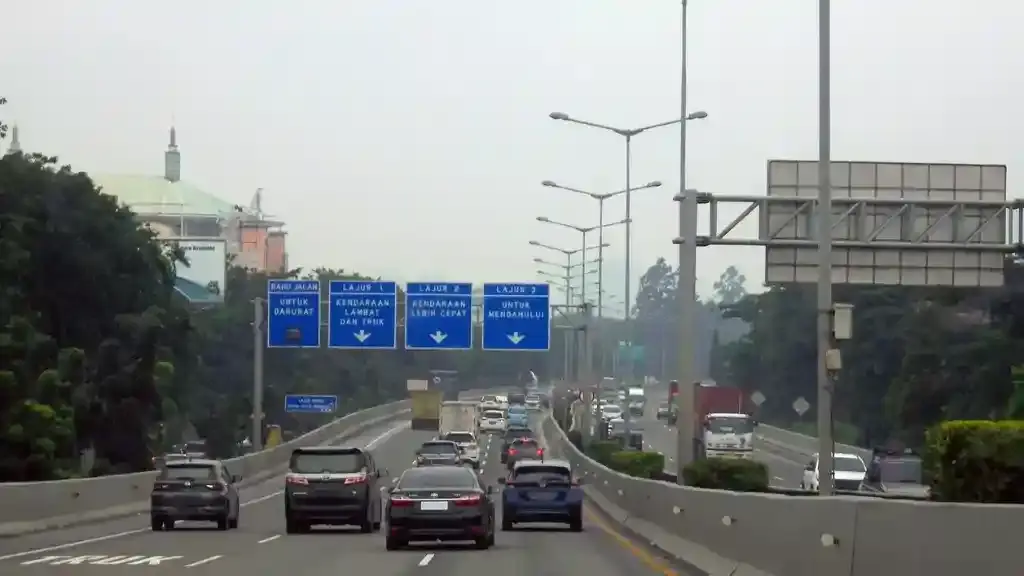

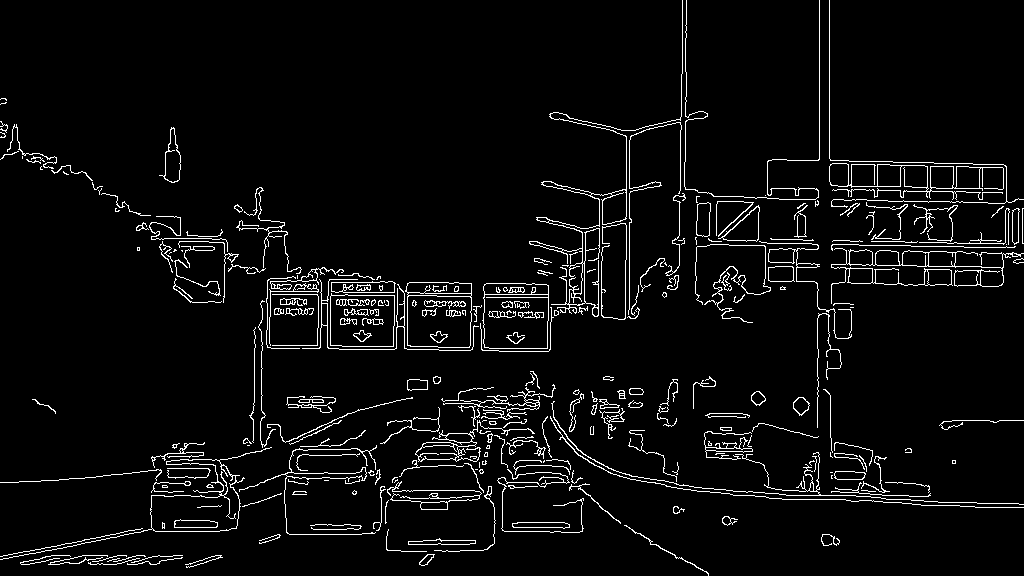

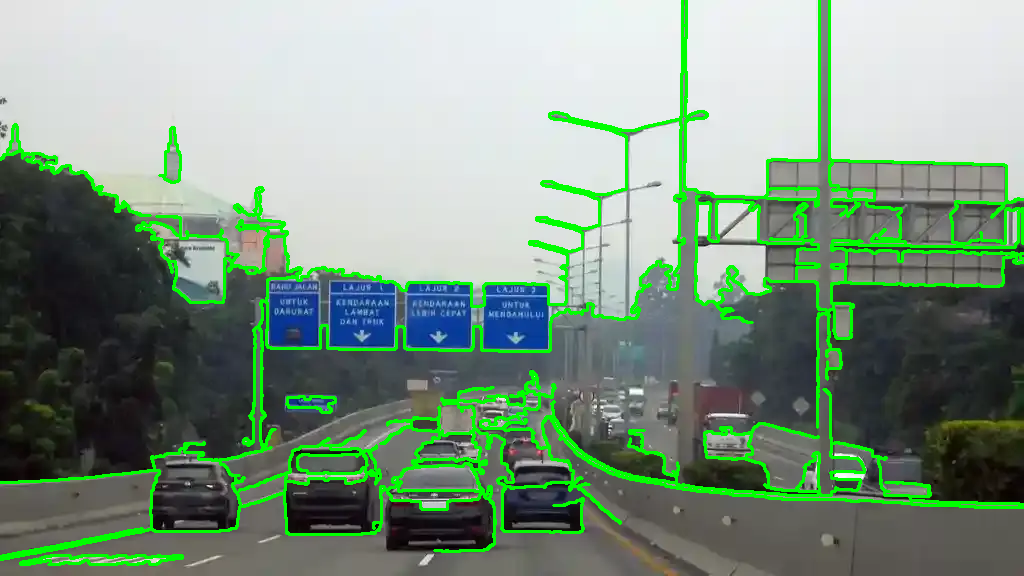

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Baca gambar
img = cv2.imread('jalan.webp')
img_copy = img.copy()

# Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Blur
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Edge detection
edges = cv2.Canny(blur, 50, 150)

# Morfologi
kernel = np.ones((3,3), np.uint8)
dilasi = cv2.dilate(edges, kernel, iterations=1)
erosi = cv2.erode(dilasi, kernel, iterations=1)

# Cari kontur
contours, _ = cv2.findContours(erosi, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Gambar kontur saja (tanpa kotak)
for cnt in contours:
    area = cv2.contourArea(cnt)

    if area > 500:  # filter noise
        cv2.drawContours(img_copy, [cnt], -1, (0,255,0), 2)

# Tampilkan hasil
cv2_imshow(img)
cv2_imshow(edges)
cv2_imshow(img_copy)